In [14]:
# Importation des packages

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
# Chargement du Dataset

data = pd.read_csv('../data/raw/cost-of-living.csv')

In [9]:
# Exploration du Dataset
print("Taille du Dataset")
print(data.shape)
print("\n5 premières lignes du Dataset")
print(data.head())
print("\n Infos sur les types et les valeurs manquantes")
print(data.info())
print("\n Résumé statistique")
print(data.describe())
# Valeurs manquantes en détail
print("Valeurs manquantes par colonne :")
print(data.isnull().sum())
print("\nPourcentage de valeurs manquantes :")
print((data.isnull().sum() / len(data) * 100).round(2))

Taille du Dataset
(4874, 59)

5 premières lignes du Dataset
   Unnamed: 0      city      country    x1     x2    x3    x4    x5    x6  \
0           0     Delhi        India  4.90  22.04  4.28  1.84  3.67  1.78   
1           1  Shanghai        China  5.59  40.51  5.59  1.12  4.19  3.96   
2           2   Jakarta    Indonesia  2.54  22.25  3.50  2.02  3.18  2.19   
3           3    Manila  Philippines  3.54  27.40  3.54  1.24  1.90  2.91   
4           4     Seoul  South Korea  7.16  52.77  6.03  3.02  4.52  3.86   

     x7  ...     x47      x48     x49      x50      x51       x52       x53  \
0  0.48  ...   36.26   223.87  133.38   596.16   325.82   2619.46   1068.90   
1  0.52  ...  121.19  1080.07  564.30  2972.57  1532.23  17333.09   9174.88   
2  0.59  ...   80.32   482.85  270.15  1117.69   584.37   2694.05   1269.44   
3  0.93  ...   61.82   559.52  281.78  1754.40   684.81   3536.04   2596.44   
4  1.46  ...  108.30   809.83  583.60  2621.05  1683.74  21847.94  10832.90   

  

In [12]:
# Nettoyage du Dataset
# x1–x27, x36, x38, x41, x44, x47 < 15% -> Médiane par pays
# x28, x30–x35, x37, x39, x42, x48–x51, x54, x55 15% – 35% -> Médiane par pays
# x29, x40, x43, x52, x53 > 40% -> Supprimer la colonne

# Seuil à 40%
threshold = 40

# Calculer le pourcentage de valeurs manquantes par colonne
missing_percent = (data.isnull().sum() / len(data) * 100)

# Trouver les colonnes dont le % dépasse le seuil
cols_to_drop = missing_percent[missing_percent > threshold].index.tolist()

print(f"Colonnes supprimées ({len(cols_to_drop)}) : {cols_to_drop}")

# Supprimer ces colonnes
data.drop(columns=cols_to_drop, inplace=True)

print(f"\nNouvelle taille du dataset : {data.shape}")

# Sélectionner toutes les colonnes numériques restantes
cols_to_impute = data.select_dtypes(include='number').columns.tolist()

# Retirer 'Unnamed: 0' si elle est présente (c'est juste un index)
if 'Unnamed: 0' in cols_to_impute:
    cols_to_impute.remove('Unnamed: 0')

print(f"Colonnes à imputer ({len(cols_to_impute)}) : {cols_to_impute}")

# Imputation par la médiane groupée par pays
data[cols_to_impute] = data.groupby('country')[cols_to_impute].transform(
    lambda x: x.fillna(x.median())
)

# Cas limite : si une ville est seule dans son pays → médiane globale
data[cols_to_impute] = data[cols_to_impute].fillna(data[cols_to_impute].median())

# Vérification finale
remaining_nulls = data.isnull().sum().sum()
print(f"\nValeurs manquantes restantes : {remaining_nulls} ")

# Supprimer la colonne index inutile
if 'Unnamed: 0' in data.columns:
    data.drop(columns=['Unnamed: 0'], inplace=True)
    print("Colonne 'Unnamed: 0' supprimée ")

before = len(data)
data.drop_duplicates(inplace=True)
after = len(data)
print(f"Doublons supprimés : {before - after}")

# Renommage des colonnes pour qu'elles soient significatives
rename_map = {
    'x1': 'meal_cheap_restaurant',
    'x2': 'meal_for_2_mid_restaurant',
    'x3': 'mcmeal',
    'x4': 'domestic_beer_restaurant',
    'x5': 'imported_beer_restaurant',
    'x6': 'cappuccino',
    'x7': 'coke_pepsi',
    'x8': 'water_restaurant',
    'x9': 'milk_1l',
    'x10': 'bread_500g',
    'x11': 'rice_1kg',
    'x12': 'eggs_12',
    'x13': 'cheese_1kg',
    'x14': 'chicken_1kg',
    'x15': 'beef_1kg',
    'x16': 'apples_1kg',
    'x17': 'banana_1kg',
    'x18': 'oranges_1kg',
    'x19': 'tomato_1kg',
    'x20': 'potato_1kg',
    'x21': 'onion_1kg',
    'x22': 'lettuce_1head',
    'x23': 'water_1_5l',
    'x24': 'wine_bottle',
    'x25': 'domestic_beer_market',
    'x26': 'imported_beer_market',
    'x27': 'cigarettes_20pack',
    'x28': 'one_way_ticket',
    'x30': 'monthly_pass_transport',
    'x31': 'taxi_start',
    'x32': 'taxi_1km',
    'x33': 'taxi_1hr_wait',
    'x34': 'gasoline_1l',
    'x35': 'volkswagen_golf',
    'x36': 'apartment_1br_city',
    'x37': 'apartment_1br_outside',
    'x38': 'apartment_3br_city',
    'x39': 'apartment_3br_outside',
    'x41': 'utilities_monthly',
    'x42': 'mobile_plan_monthly',
    'x44': 'internet_monthly',
    'x45': 'fitness_club_monthly',
    'x46': 'tennis_court_hr',
    'x47': 'cinema_ticket',
    'x48': 'preschool_monthly',
    'x49': 'intl_school_yearly',
    'x50': 'jeans_levis',
    'x51': 'summer_dress',
    'x54': 'avg_net_salary',
    'x55': 'mortgage_rate'
}

data.rename(columns=rename_map, inplace=True)
print("Colonnes renommées ")
print(data.columns.tolist())

# Sauvegarder le dataset nettoyé
data.to_csv('../data/processed/cost_of_living_cleaned.csv', index=False)
print("\nDataset nettoyé sauvegardé dans data/processed/ ")

Colonnes supprimées (0) : []

Nouvelle taille du dataset : (4874, 54)
Colonnes à imputer (52) : ['meal_cheap_restaurant', 'meal_for_2_mid_restaurant', 'mcmeal', 'domestic_beer_restaurant', 'imported_beer_restaurant', 'cappuccino', 'coke_pepsi', 'water_restaurant', 'milk_1l', 'bread_500g', 'rice_1kg', 'eggs_12', 'cheese_1kg', 'chicken_1kg', 'beef_1kg', 'apples_1kg', 'banana_1kg', 'oranges_1kg', 'tomato_1kg', 'potato_1kg', 'onion_1kg', 'lettuce_1head', 'water_1_5l', 'wine_bottle', 'domestic_beer_market', 'imported_beer_market', 'cigarettes_20pack', 'one_way_ticket', 'monthly_pass_transport', 'taxi_start', 'taxi_1km', 'taxi_1hr_wait', 'gasoline_1l', 'volkswagen_golf', 'apartment_1br_city', 'apartment_1br_outside', 'apartment_3br_city', 'apartment_3br_outside', 'utilities_monthly', 'mobile_plan_monthly', 'x43', 'internet_monthly', 'fitness_club_monthly', 'tennis_court_hr', 'cinema_ticket', 'preschool_monthly', 'intl_school_yearly', 'jeans_levis', 'summer_dress', 'avg_net_salary', 'mortgage

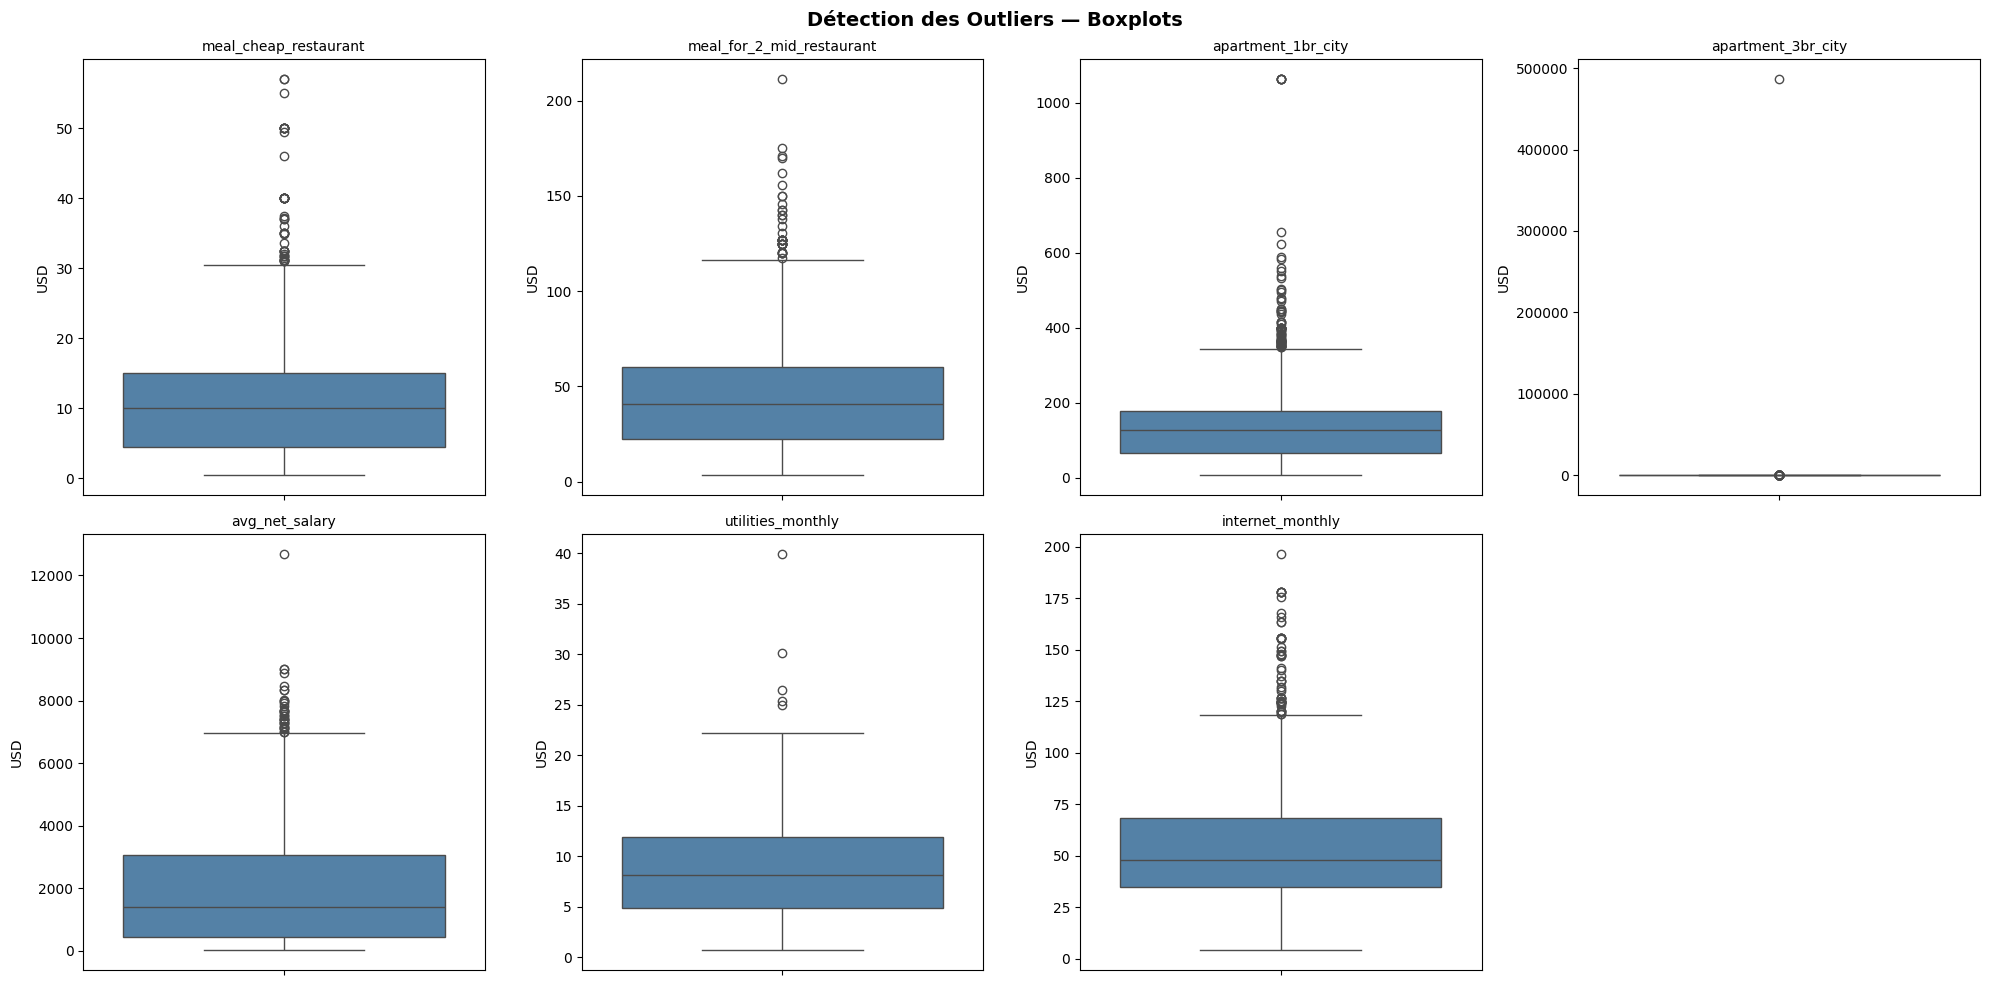

In [15]:
# Visualisation

# 1. BOXPLOTS — Détection des outliers
cols_boxplot = [
    'meal_cheap_restaurant', 'meal_for_2_mid_restaurant',
    'apartment_1br_city', 'apartment_3br_city',
    'avg_net_salary', 'utilities_monthly', 'internet_monthly'
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cols_boxplot):
    sns.boxplot(y=data[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('USD')

axes[-1].set_visible(False)
plt.suptitle('Détection des Outliers — Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

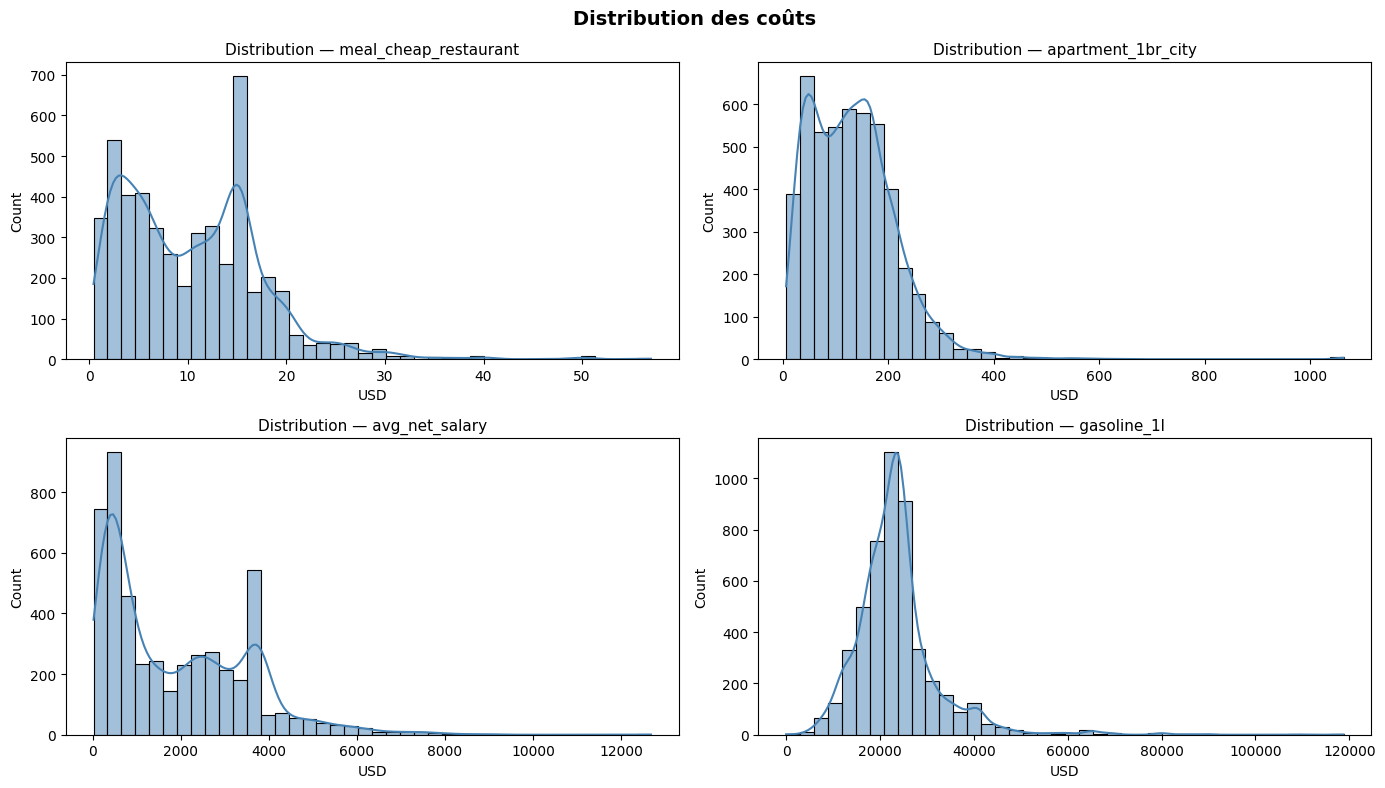

In [16]:
# DISTRIBUTIONS — Histogrammes
cols_dist = [
    'meal_cheap_restaurant', 'apartment_1br_city',
    'avg_net_salary', 'gasoline_1l'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cols_dist):
    sns.histplot(data[col], bins=40, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution — {col}', fontsize=11)
    axes[i].set_xlabel('USD')

plt.suptitle('Distribution des coûts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\mamao\AppData\Local\Temp\ipykernel_6840\1979951958.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_expensive, x='avg_cost', y='country', palette='Reds_r')


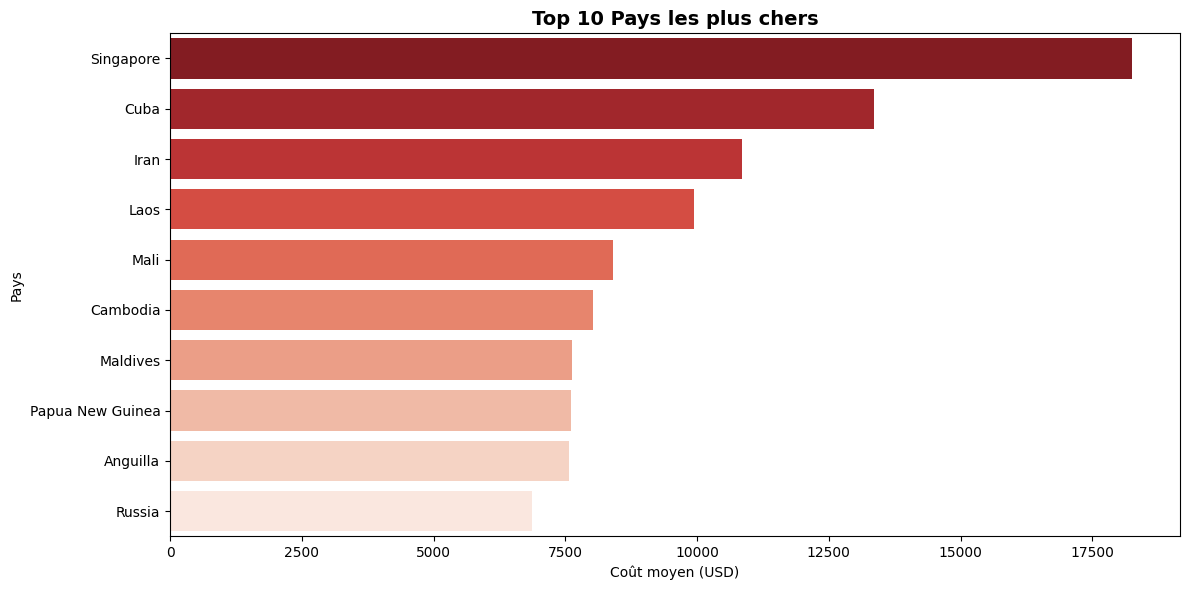

In [17]:
#  3. TOP 10 PAYS LES PLUS CHERS
cost_cols = [
    'meal_cheap_restaurant', 'meal_for_2_mid_restaurant',
    'apartment_1br_city', 'utilities_monthly',
    'internet_monthly', 'gasoline_1l'
]

data['avg_cost'] = data[cost_cols].mean(axis=1)

top10_expensive = (
    data.groupby('country')['avg_cost']
    .median()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=top10_expensive, x='avg_cost', y='country', palette='Reds_r')
plt.title('Top 10 Pays les plus chers', fontsize=14, fontweight='bold')
plt.xlabel('Coût moyen (USD)')
plt.ylabel('Pays')
plt.tight_layout()
plt.show()

C:\Users\mamao\AppData\Local\Temp\ipykernel_6840\3046119562.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_cheapest, x='avg_cost', y='country', palette='Greens_r')


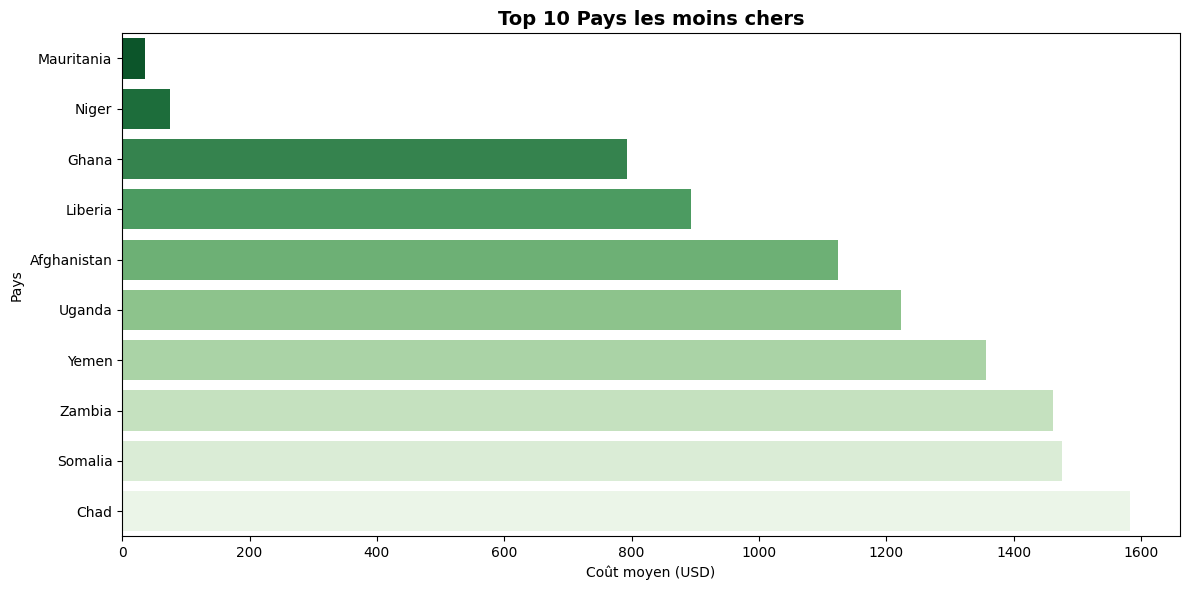

In [18]:
# 4. TOP 10 PAYS LES MOINS CHERS
top10_cheapest = (
    data.groupby('country')['avg_cost']
    .median()
    .sort_values(ascending=True)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=top10_cheapest, x='avg_cost', y='country', palette='Greens_r')
plt.title('Top 10 Pays les moins chers', fontsize=14, fontweight='bold')
plt.xlabel('Coût moyen (USD)')
plt.ylabel('Pays')
plt.tight_layout()
plt.show()

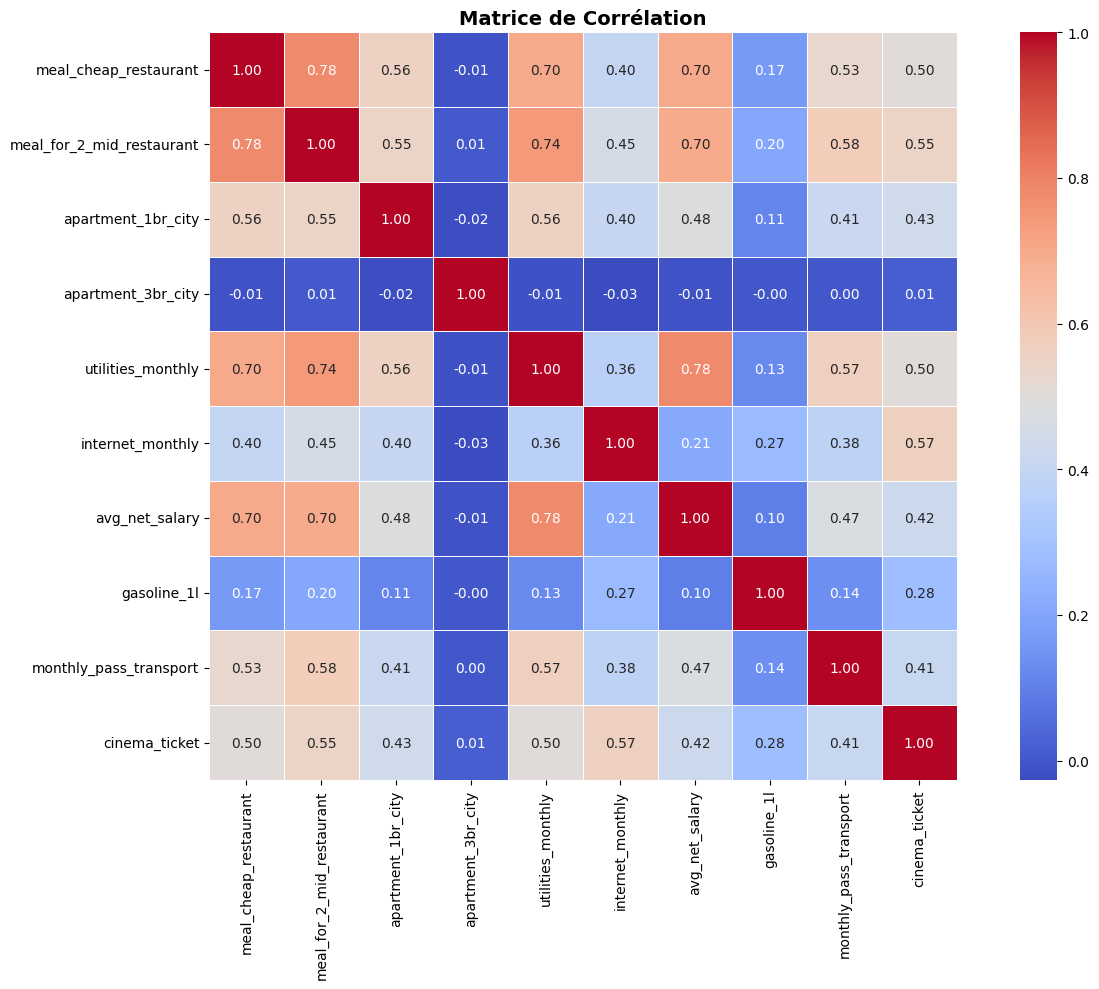

In [19]:
# 5. HEATMAP — Corrélations
corr_cols = [
    'meal_cheap_restaurant', 'meal_for_2_mid_restaurant',
    'apartment_1br_city', 'apartment_3br_city',
    'utilities_monthly', 'internet_monthly',
    'avg_net_salary', 'gasoline_1l',
    'monthly_pass_transport', 'cinema_ticket'
]

plt.figure(figsize=(14, 10))
corr_matrix = data[corr_cols].corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True
)
plt.title('Matrice de Corrélation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

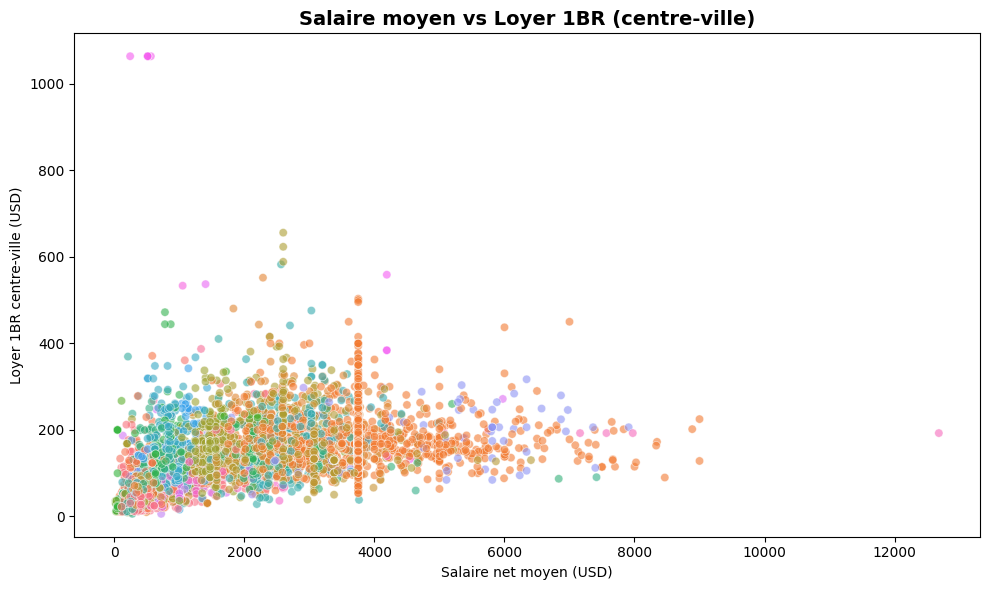

In [20]:
# 6. SALAIRE VS COÛT DE LA VIE
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=data,
    x='avg_net_salary',
    y='apartment_1br_city',
    hue='country',
    alpha=0.6,
    legend=False
)
plt.title('Salaire moyen vs Loyer 1BR (centre-ville)', fontsize=14, fontweight='bold')
plt.xlabel('Salaire net moyen (USD)')
plt.ylabel('Loyer 1BR centre-ville (USD)')
plt.tight_layout()
plt.show()